In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/massachusetts-roads-dataset")

print("Path to dataset files:", path)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 5.76G/5.76G [10:24<00:00, 9.91MB/s]

Extracting files...


Path to dataset files: /Users/brycewishart/.cache/kagglehub/datasets/balraj98/massachusetts-roads-dataset/versions/1


## 1. Imports & Configuration

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path(r"C:\Users\bryce\.cache\kagglehub\datasets\balraj98\massachusetts-roads-dataset\versions\1")

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = 512   # resize both spatial dims to this
BATCH_SIZE  = 8
# Windows uses 'spawn' for multiprocessing — num_workers=0 is faster here
NUM_WORKERS = 0 if os.name == "nt" else 4

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"NUM_WORKERS : {NUM_WORKERS}")
print(f"Dataset root: {DATASET_ROOT}")

Device      : cuda
GPU         : NVIDIA GeForce RTX 4070
NUM_WORKERS : 0
Dataset root: C:\Users\bryce\.cache\kagglehub\datasets\balraj98\massachusetts-roads-dataset\versions\1


## 2. Dataset Exploration

In [3]:
meta = pd.read_csv(DATASET_ROOT / "metadata.csv")
print("Metadata shape:", meta.shape)
print("\nSplit counts:")
print(meta["split"].value_counts())
print("\nColumns:", meta.columns.tolist())
meta.head(3)

Metadata shape: (1171, 8)

Split counts:
split
train    1108
test       49
val        14
Name: count, dtype: int64

Columns: ['image_id', 'split', 'image_souce_url', 'label_source_url', 'tiff_image_path', 'tif_label_path', 'png_image_path', 'png_label_path']


,image_id,split,image_souce_url,label_source_url,tiff_image_path,tif_label_path,png_image_path,png_label_path
0,10078660_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078660_15.tiff,tiff/train_labels/10078660_15.tif,png/train/10078660_15.png,png/train_labels/10078660_15.png
1,10078675_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078675_15.tiff,tiff/train_labels/10078675_15.tif,png/train/10078675_15.png,png/train_labels/10078675_15.png
2,10078690_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078690_15.tiff,tiff/train_labels/10078690_15.tif,png/train/10078690_15.png,png/train_labels/10078690_15.png


Image  — size: (1500, 1500), dtype: uint8, min/max: 0/255
Label  — size: (1500, 1500), dtype: uint8, unique values: [  0 255]
Road coverage: 1.24%


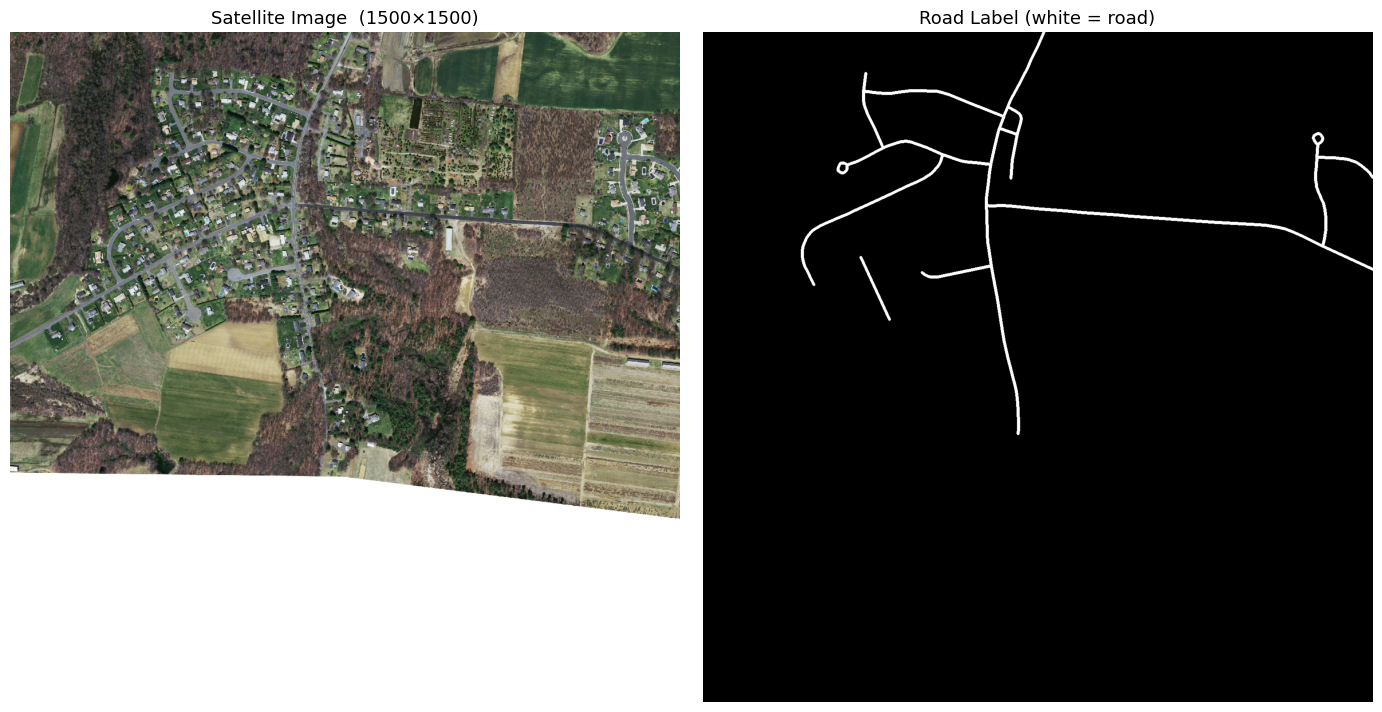

In [4]:
# Inspect a single image/label pair
row = meta[meta["split"] == "train"].iloc[0]
img_path   = DATASET_ROOT / row["tiff_image_path"]
label_path = DATASET_ROOT / row["tif_label_path"]

img   = Image.open(img_path).convert("RGB")
label = Image.open(label_path).convert("L")

img_arr   = np.array(img)
label_arr = np.array(label)

print(f"Image  — size: {img.size}, dtype: {img_arr.dtype}, "
      f"min/max: {img_arr.min()}/{img_arr.max()}")
print(f"Label  — size: {label.size}, dtype: {label_arr.dtype}, "
      f"unique values: {np.unique(label_arr)}")
print(f"Road coverage: {(label_arr > 0).mean() * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_arr)
axes[0].set_title(f"Satellite Image  ({img.size[0]}×{img.size[1]})", fontsize=13)
axes[0].axis("off")
axes[1].imshow(label_arr, cmap="gray")
axes[1].set_title("Road Label (white = road)", fontsize=13)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset Class

In [5]:
class MassRoadsDataset(Dataset):
    """
    Massachusetts Roads Dataset — binary road segmentation.

    Each sample is a (image, mask) pair where:
      image : FloatTensor [3, H, W]  — normalized RGB satellite image
      mask  : FloatTensor [1, H, W]  — binary road mask (1 = road, 0 = background)
    """

    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(
        self,
        metadata: pd.DataFrame,
        root: Path,
        split: str,
        img_size: int = 512,
        augment: bool = False,
    ):
        self.root         = root
        self.img_size     = img_size
        self.augment      = augment
        self.normalize    = T.Normalize(mean=self.MEAN, std=self.STD)
        self.color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
        self.samples      = (
            metadata[metadata["split"] == split]
            .reset_index(drop=True)
        )

    def __len__(self) -> int:
        return len(self.samples)

    def _load_pair(self, idx: int):
        row   = self.samples.iloc[idx]
        img   = Image.open(self.root / row["tiff_image_path"]).convert("RGB")
        label = Image.open(self.root / row["tif_label_path"]).convert("L")
        return img, label

    def _apply_transforms(self, img: Image.Image, label: Image.Image):
        img   = TF.resize(img,   [self.img_size, self.img_size],
                          interpolation=T.InterpolationMode.BILINEAR, antialias=True)
        label = TF.resize(label, [self.img_size, self.img_size],
                          interpolation=T.InterpolationMode.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                img, label = TF.hflip(img), TF.hflip(label)
            if random.random() > 0.5:
                img, label = TF.vflip(img), TF.vflip(label)
            angle = random.choice([0, 90, 180, 270])
            if angle:
                img   = TF.rotate(img,   angle)
                label = TF.rotate(label, angle)
            img = self.color_jitter(img)

        img   = TF.to_tensor(img)
        label = TF.to_tensor(label)
        label = (label > 0.5).float()
        img   = self.normalize(img)
        return img, label

    def __getitem__(self, idx: int):
        img, label = self._load_pair(idx)
        return self._apply_transforms(img, label)

    @staticmethod
    def denormalize(tensor: torch.Tensor) -> torch.Tensor:
        mean = torch.tensor(MassRoadsDataset.MEAN).view(3, 1, 1)
        std  = torch.tensor(MassRoadsDataset.STD).view(3, 1, 1)
        return (tensor * std + mean).clamp(0, 1)


print("MassRoadsDataset class defined.")

MassRoadsDataset class defined.


## 4. DataLoaders

In [6]:
def seed_worker(worker_id: int) -> None:
    """Ensure each DataLoader worker has a unique but reproducible seed."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

_generator = torch.Generator()
_generator.manual_seed(SEED)

train_ds = MassRoadsDataset(meta, DATASET_ROOT, split="train", img_size=IMG_SIZE, augment=True)
val_ds   = MassRoadsDataset(meta, DATASET_ROOT, split="val",   img_size=IMG_SIZE, augment=False)
test_ds  = MassRoadsDataset(meta, DATASET_ROOT, split="test",  img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=_generator,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train : {len(train_ds):>5} images → {len(train_loader):>4} batches (augmented)")
print(f"Val   : {len(val_ds):>5} images → {len(val_loader):>4} batches")
print(f"Test  : {len(test_ds):>5} images → {len(test_loader):>4} batches")
print(f"\nTensor shape per sample: image [3, {IMG_SIZE}, {IMG_SIZE}]  |  mask [1, {IMG_SIZE}, {IMG_SIZE}]")

Train :  1108 images →  139 batches (augmented)
Val   :    14 images →    2 batches
Test  :    49 images →    7 batches

Tensor shape per sample: image [3, 512, 512]  |  mask [1, 512, 512]


## 5. Sanity Check

Loaded 4 samples in 0.1s
Batch — images: (4, 3, 512, 512)  masks: (4, 1, 512, 512)
Image  — dtype: torch.float32,  min: -2.118,  max: 2.553
Mask   — unique values: [0.0, 1.0]
Avg road coverage: 1.78%


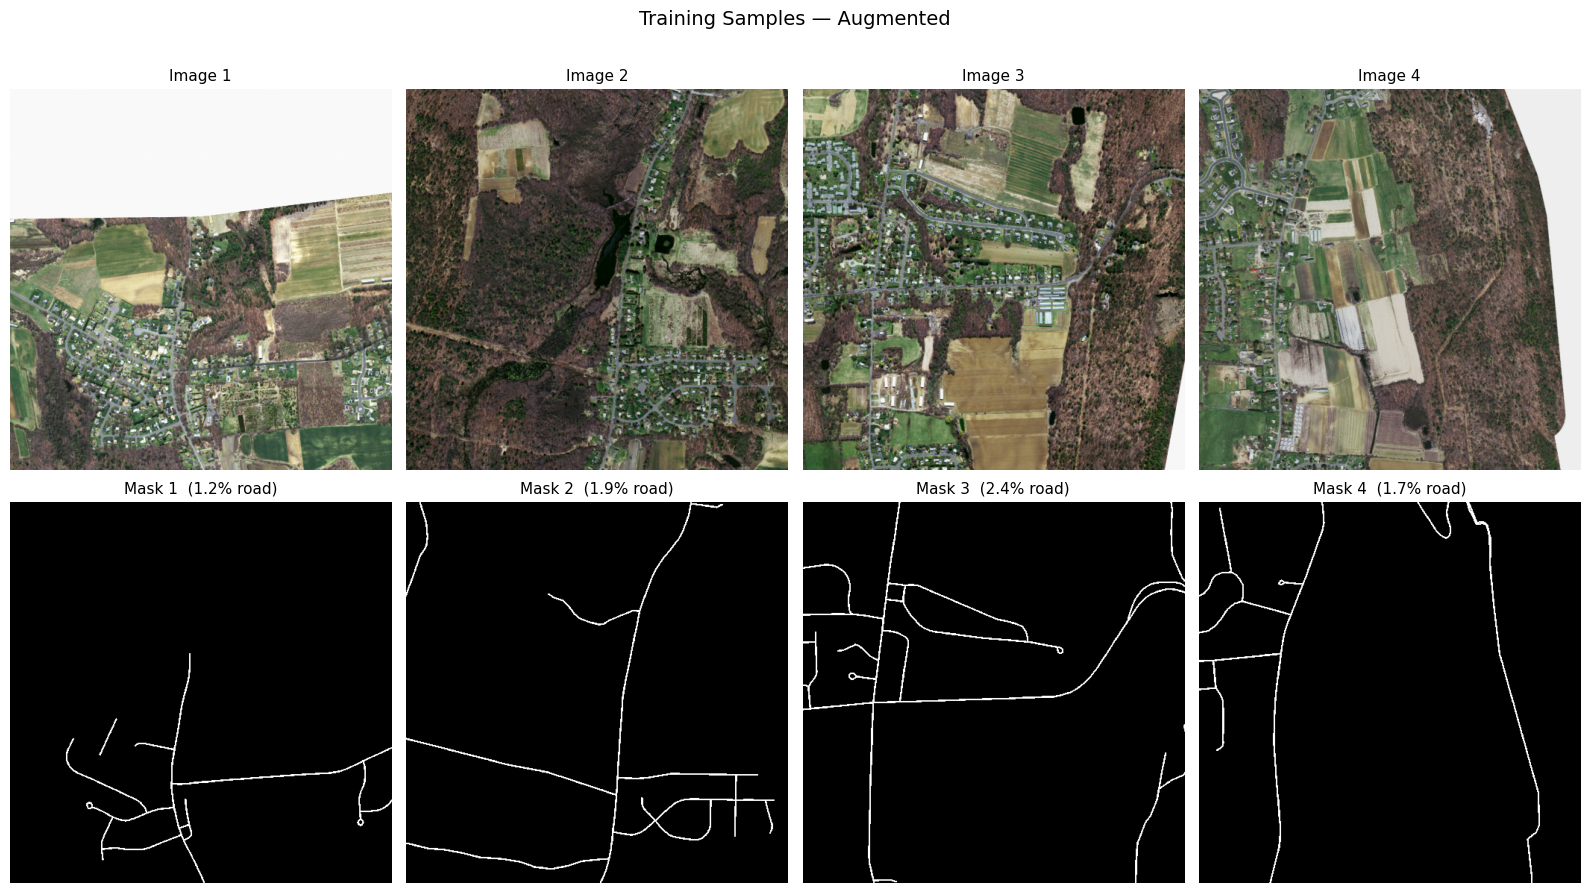

In [7]:
import time

# Load 4 samples directly — avoids DataLoader/worker overhead for a quick check
N_SAMPLES = 4
t0 = time.time()
samples = [train_ds[i] for i in range(N_SAMPLES)]
imgs  = torch.stack([s[0] for s in samples])
masks = torch.stack([s[1] for s in samples])
print(f"Loaded {N_SAMPLES} samples in {time.time() - t0:.1f}s")

print(f"Batch — images: {tuple(imgs.shape)}  masks: {tuple(masks.shape)}")
print(f"Image  — dtype: {imgs.dtype},  min: {imgs.min():.3f},  max: {imgs.max():.3f}")
print(f"Mask   — unique values: {masks.unique().tolist()}")
print(f"Avg road coverage: {masks.mean() * 100:.2f}%")

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 9))
for i in range(N_SAMPLES):
    vis_img  = MassRoadsDataset.denormalize(imgs[i]).permute(1, 2, 0).numpy()
    vis_mask = masks[i, 0].numpy()

    axes[0, i].imshow(vis_img)
    axes[0, i].set_title(f"Image {i + 1}", fontsize=11)
    axes[0, i].axis("off")

    axes[1, i].imshow(vis_mask, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Mask {i + 1}  ({vis_mask.mean()*100:.1f}% road)", fontsize=11)
    axes[1, i].axis("off")

plt.suptitle("Training Samples — Augmented", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()